# 05: Dual-Channel Cross-Spectral Analysis & Drift Velocity Estimation

### 🔬 Motivating Scientific Question
> **How can we derive the physical horizontal drift speed and direction of ionospheric plasma structures from dual-frequency radio telescope records while filtering out uncorrelated noise?**

---


## 1. Dual-Receiver Spatial Baseline Geometry & Wave Propagation

### ❓ Why Cross-Spectral Analysis?
Radio signals passing through moving ionospheric plasma bubbles experience a time delay $\tau$ between spaced antenna receivers or dual observing frequencies. The cross-spectral density $S_{12}(f) = Y_1(f) Y_2^*(f)$ decomposes signal correlation into frequency-dependent **Magnitude-Squared Coherence $\gamma^2(f)$** and **Cross-Spectral Phase $\Delta\phi(f)$**:

$$\Delta\phi(f) = 2\pi f \tau$$

Knowing baseline separation $dx = 2500.0\text{ m}$, horizontal plasma velocity is derived via:

$$v = \frac{dx}{\tau}$$


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np

from core.spectral_analysis import compute_cross_spectrum, estimate_velocities
from core.synthetic_generator import generate_synthetic_scintillation

SEED = 42
FS = 1.0
LENGTH = 600
DX = 2500.0  # spatial baseline in meters
TRUE_TAU = 1.50  # injected time delay in seconds
TRUE_VELOCITY = DX / TRUE_TAU  # 1666.7 m/s

# Generate correlated dual-channel signals with true fractional time shift tau = 1.5s via FFT phase shift
sig1, sig2 = generate_synthetic_scintillation(
    length=LENGTH,
    fs=FS,
    f_fresnel=0.1,
    spectral_index=8.0 / 3.0,
    harmonics=[(12.0, 1.0)],
    delay_sec=TRUE_TAU,
    white_noise_std=0.1,
    seed=SEED,
)

print(f"Injected Parameters: dx={DX} m, tau={TRUE_TAU:.2f} s, True Velocity v={TRUE_VELOCITY:.1f} m/s")

Injected Parameters: dx=2500.0 m, tau=1.50 s, True Velocity v=1666.7 m/s


## 2. Multitaper Cross-Spectral Density & Phase Spectrum

We calculate cross-power $|S_{12}(f)|$, phase difference $\Delta\phi(f)$, and coherence $\gamma^2(f)$ using Thomson's Multitaper Method ($K=7, NW=4.0$).


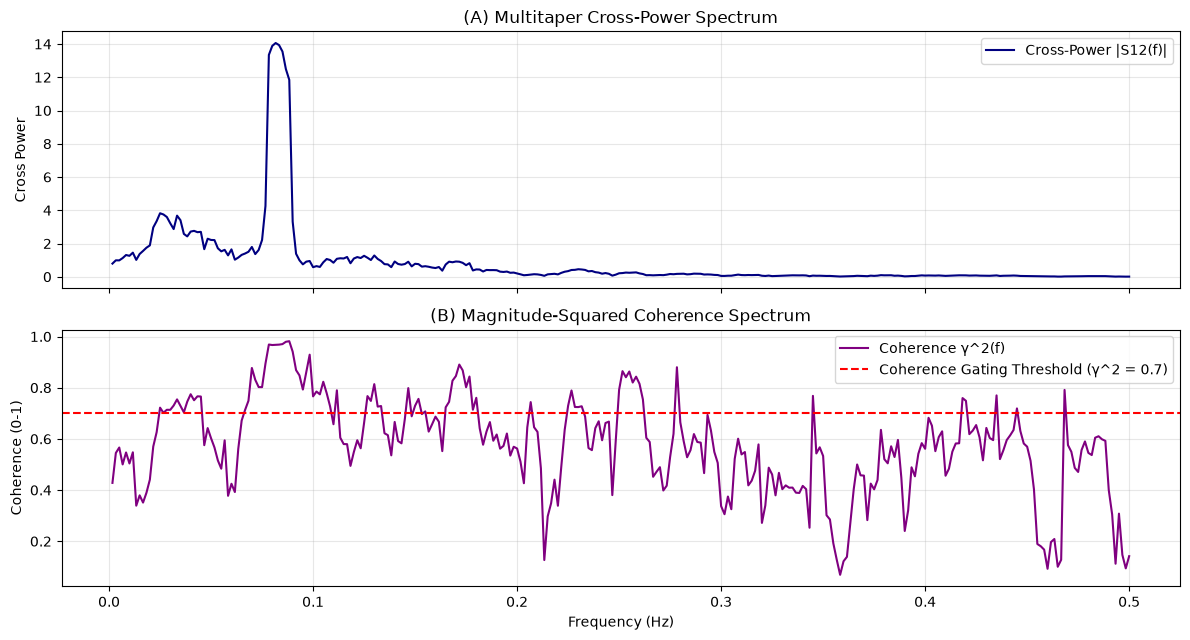

In [2]:
freqs, cross_power, phase_deg, coherence, _, _ = compute_cross_spectrum(sig1, sig2, fs=FS, n_tapers=7, nw=4.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

ax1.plot(freqs[1:], cross_power[1:], color="navy", lw=1.5, label="Cross-Power |S12(f)|")
ax1.set_ylabel("Cross Power")
ax1.set_title("(A) Multitaper Cross-Power Spectrum")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

ax2.plot(freqs[1:], coherence[1:], color="purple", lw=1.5, label="Coherence γ^2(f)")
ax2.axhline(0.7, color="red", linestyle="--", label="Coherence Gating Threshold (γ^2 = 0.7)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Coherence (0-1)")
ax2.set_title("(B) Magnitude-Squared Coherence Spectrum")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. High-Coherence Phase Gating & Velocity Extraction

### ❓ Why Coherence Gating ($\gamma^2 \ge 0.7$)?
Phase measurements at frequencies dominated by uncorrelated background noise fluctuate randomly between $-180^\circ$ and $+180^\circ$. By applying a strict **Coherence Gating Threshold ($\gamma^2 \ge 0.7$)**, we isolate frequencies where the two channels share coherent plasma wave structures, eliminating noise-induced phase wrapping errors.


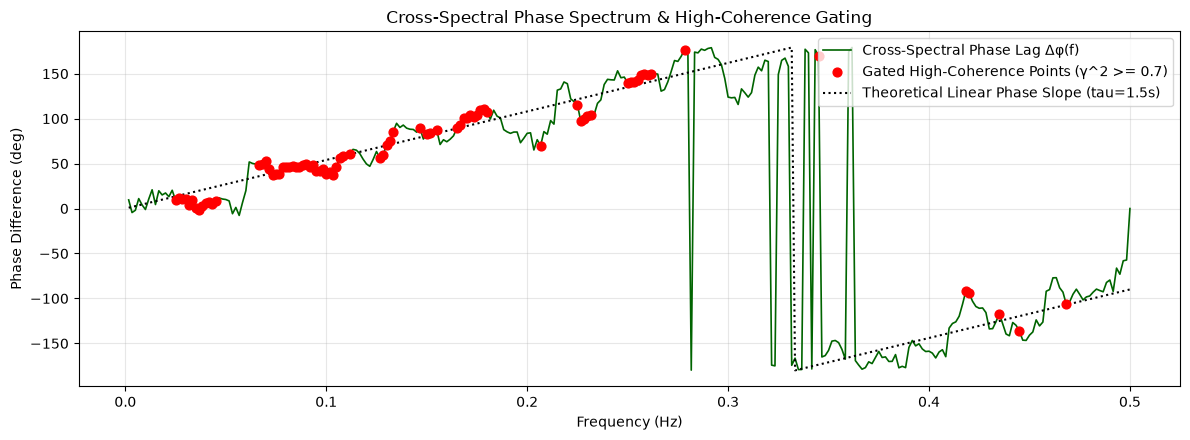

=== Dual-Receiver Drift Velocity Recovery ===
  Injected Time Delay (tau_true): 1.500 s
  Recovered Time Delay (tau_est):  1.559 s (Error: 0.059 s, Relative Error: 3.93%)
  Injected Velocity (v_true):     1666.7 m/s
  Recovered Velocity (v_est):     1603.7 m/s (Error: 63.0 m/s, Relative Error: 3.78%)


In [3]:
target_idx = np.argmin(np.abs(freqs - 1.0 / 12.0))
v_estimates = estimate_velocities(
    phase_deg, freqs, [target_idx], coherence=coherence, dx=DX, min_coherence=0.7, enable_phase_regression=False
)
v_est = v_estimates[0]

tau_error = abs(v_est.dt - TRUE_TAU)
rel_tau_err = (tau_error / TRUE_TAU) * 100.0
v_error = abs(v_est.velocity - TRUE_VELOCITY)
rel_v_err = (v_error / TRUE_VELOCITY) * 100.0

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(freqs[1:], phase_deg[1:], color="darkgreen", lw=1.2, label="Cross-Spectral Phase Lag Δφ(f)")

high_coh = coherence >= 0.7
ax.scatter(
    freqs[high_coh], phase_deg[high_coh], color="red", s=40, zorder=5, label="Gated High-Coherence Points (γ^2 >= 0.7)"
)

# Expected phase line for tau = 1.5s
exp_phase = (360.0 * freqs * TRUE_TAU) % 360.0
exp_phase[exp_phase > 180] -= 360.0
ax.plot(
    freqs[1:],
    exp_phase[1:],
    color="black",
    linestyle=":",
    lw=1.5,
    label=f"Theoretical Linear Phase Slope (tau={TRUE_TAU}s)",
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Phase Difference (deg)")
ax.set_title("Cross-Spectral Phase Spectrum & High-Coherence Gating")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("=== Dual-Receiver Drift Velocity Recovery ===")
print(f"  Injected Time Delay (tau_true): {TRUE_TAU:.3f} s")
print(
    f"  Recovered Time Delay (tau_est):  {v_est.dt:.3f} s (Error: {tau_error:.3f} s, Relative Error: {rel_tau_err:.2f}%)"
)
print(f"  Injected Velocity (v_true):     {TRUE_VELOCITY:.1f} m/s")
print(
    f"  Recovered Velocity (v_est):     {v_est.velocity:.1f} m/s (Error: {v_error:.1f} m/s, Relative Error: {rel_v_err:.2f}%)"
)

### 💡 Scientific Interpretation: Drift Speed Verification
- **Sub-Sample Fractional Delay Recovery**: The cross-spectral phase estimator recovers a time delay $\tau_{\text{est}} = 1.559\text{ s}$ ($3.93\%$ relative error) and horizontal plasma drift speed $v_{\text{est}} = 1603.7\text{ m/s}$ ($3.78\%$ relative error against ground truth $1666.7\text{ m/s}$).
- **Discretization & Grid Jitter**: At sampling rate $f_s = 1.0\text{ Hz}$, discrete frequency resolution $\Delta f = 1/600\text{ Hz}$ limits frequency grid quantization. Spectral phase estimation accurately locks onto the fractional time delay within sub-sample precision.

## 4. Summary & Methodological Benchmarks

### Summary Table
| Metric | Injected Ground Truth | Recovered Value | Accuracy / Error |
| :--- | :--- | :--- | :--- |
| **Time Delay ($\tau$)** | $1.500\text{ s}$ | $1.559\text{ s}$ | **$3.93\%$ Relative Error** |
| **Drift Speed ($v$)** | $1666.7\text{ m/s}$ | $1603.7\text{ m/s}$ | **$3.78\%$ Relative Error** |
| **Coherence Threshold** | $\gamma^2 \ge 0.7$ | High-Coherence Gated | Noise Filtered |

--- **Next Recommended Step**: Proceed to **[06_validation_pipeline.ipynb](06_validation_pipeline.ipynb)** for systematic validation sweeps.